In [4]:
import numpy as np
from iqpy.iqp_to_qiskit import IqpCircuitQiskit
from iqpy.utils import median_heuristic_fast, generate_experiment_mixture_dataset
from iqpy.ansatzes import fully_connected_IQP_ansatz
from iqpy.torch_training import TrainerTorch
from iqpy.torch_methods import mmd_loss_torch
from qiskit import qpy

n_qubits = 5
n_ops = 200
gates = fully_connected_IQP_ansatz(n_qubits)
circuit = IqpCircuitQiskit(n_qubits, gates)

X_train = generate_experiment_mixture_dataset(n_qubits, n_samples=10000)

print(f"Training data: {len(X_train)} samples")

sigma = median_heuristic_fast(X_train, n_samples=10000)

params_init = np.random.normal(0, 1 / np.sqrt(n_qubits), len(gates))
p = (1 - np.exp(-1 / (2 * sigma**2))) / 2
ops = np.random.binomial(1, p, size=(n_ops, n_qubits))
n_iqp_samples = 10000

loss_kwargs = {
    "params": params_init,
    "circuit": circuit,
    "ground_truth": X_train,
    "ops": ops,
    "n_samples": n_iqp_samples,
}

trainer = TrainerTorch(mmd_loss_torch, lr=0.01)
trainer.train(n_iters=100, loss_kwargs=loss_kwargs)

final_circuit = circuit.iqp_circuit(trainer.final_params)
final_circuit.measure_all()
with open("circuit.qpy", "wb") as file:
    qpy.dump([final_circuit], file)


Training data: 10000 samples
Using device: cuda
Step 001 -> Loss: 0.043896
Step 010 -> Loss: 0.029700
Step 020 -> Loss: 0.022478
Step 030 -> Loss: 0.015717
Step 040 -> Loss: 0.009605
Step 050 -> Loss: 0.004557
Step 060 -> Loss: 0.001483
Step 070 -> Loss: 0.000478
Step 080 -> Loss: 0.000214
Step 090 -> Loss: 0.000153
Step 100 -> Loss: 0.000088


Counts from the original data distribution:


Text(0.5, 1.0, 'Counts from the original data')

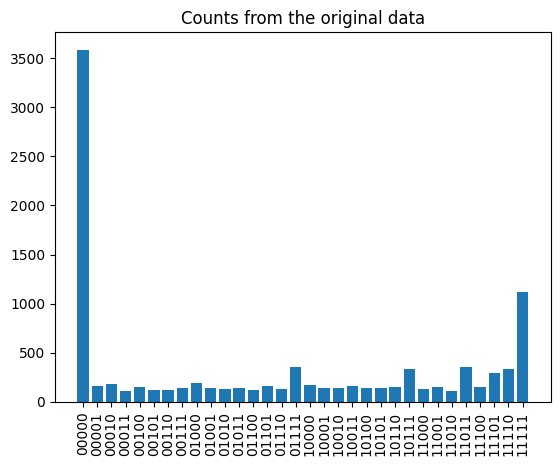

In [5]:
# Plot the counts from the original data distribution
from collections import Counter
X_train = [tuple(x) for x in X_train]
# Convert the list of tuples to a Counter object to get the counts of each unique bitstring
X_train = ["".join(str(bit) for bit in x) for x in X_train]
# Sort the bitstrings for better visualization
X_train.sort()
counts_ideal = Counter(bitstring for bitstring in X_train)
print("Counts from the original data distribution:")
#for bitstring, count in counts_ideal.items():
#    print(f"{bitstring}: {count}")
import matplotlib.pyplot as plt
plt.bar(counts_ideal.keys(), counts_ideal.values())
plt.xticks(rotation=90)
plt.title("Counts from the original data")

Counts from the trained circuit: {'00000': 327, '00001': 37, '00010': 53, '00011': 6, '00100': 46, '00101': 4, '00110': 2, '00111': 23, '01000': 30, '01001': 9, '01010': 6, '01011': 14, '01100': 10, '01101': 28, '01110': 21, '01111': 23, '10000': 39, '10001': 8, '10010': 12, '10011': 15, '10100': 6, '10101': 18, '10110': 6, '10111': 22, '11000': 2, '11001': 15, '11010': 23, '11011': 29, '11100': 19, '11101': 17, '11110': 23, '11111': 107}
Counts from the original data: {'00000': 3584, '00001': 166, '00010': 182, '00011': 115, '00100': 155, '00101': 122, '00110': 121, '00111': 138, '01000': 190, '01001': 139, '01010': 131, '01011': 146, '01100': 119, '01101': 158, '01110': 136, '01111': 360, '10000': 168, '10001': 140, '10010': 142, '10011': 162, '10100': 140, '10101': 146, '10110': 149, '10111': 335, '11000': 131, '11001': 151, '11010': 116, '11011': 353, '11100': 156, '11101': 297, '11110': 332, '11111': 1120}


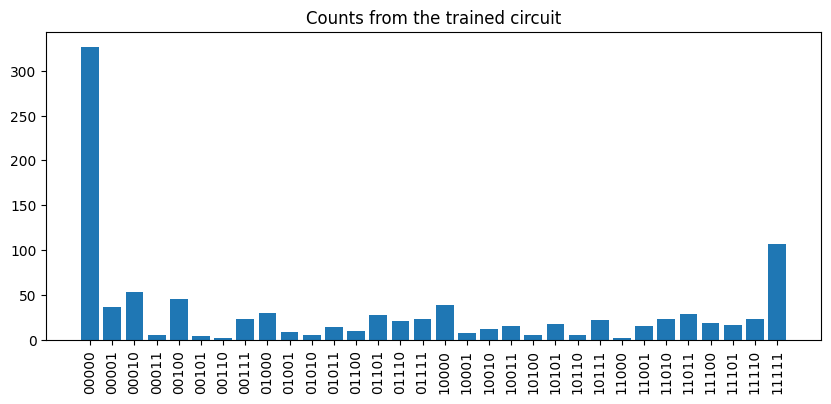

KL(data || circuit) = 0.11880031060044276


In [6]:
# Compare the distribution from the trained circuit with the original data
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from qiskit_aer.primitives import SamplerV2
from scipy.stats import entropy

sampler = SamplerV2()
result = sampler.run([final_circuit], shots=1000).result()

raw_circuit_counts = result[0].data.meas.get_counts()

# Qiskit returns bitstrings in reverse order relative to the data arrays.
# Reverse them so both distributions use the same convention.
circuit_counts = Counter({
    bitstring[::-1]: count for bitstring, count in raw_circuit_counts.items()
})
# Sort the circuit counts for better visualization
circuit_counts = Counter(dict(sorted(circuit_counts.items())))

# After Cell 2, X_train is already a list of bitstring strings.
data_counts = Counter(X_train)

print("Counts from the trained circuit:", dict(sorted(circuit_counts.items())))
print("Counts from the original data:", dict(sorted(data_counts.items())))

plt.figure(figsize=(10, 4))
plt.bar(circuit_counts.keys(), circuit_counts.values())
plt.xticks(rotation=90)
plt.title("Counts from the trained circuit")
plt.show()

def counts_to_probs(counts, keys, eps=1e-12):
    probs = np.array([counts.get(k, 0) for k in keys], dtype=float)
    probs = probs + eps
    probs = probs / probs.sum()
    return probs

all_keys = sorted(set(circuit_counts) | set(data_counts))

probs_circuit = counts_to_probs(circuit_counts, all_keys)
probs_data = counts_to_probs(data_counts, all_keys)

kl_divergence = entropy(probs_data, probs_circuit)
print(f"KL(data || circuit) = {kl_divergence}")